# Baseline Model and Results for Art Dataset

In this notebook, we implement a convolutional neural network (CNN) with residuals model to classify images as either 'real' or 'fake' faces.

## Table of Contents
1. [Imports and Setup](#imports-and-setup)
2. [Helpers functions](#helpers-functions)
3. [Load data](#load-data)
4. [Baseline model](#baseline-model)
5. [Refined model](#refined-model)
6. [Model Evaluation](#model-evaluation)
7. [Performances analysis](#performances-analysis)

### Imports and Setup

In [41]:

import math
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Input
from tensorflow.keras.layers import (
    Input, Conv2D, BatchNormalization, Activation, MaxPooling2D,
    GlobalAveragePooling2D, Dense, Dropout, Add, Flatten)
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall, AUC
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc,ConfusionMatrixDisplay, RocCurveDisplay
import numpy as np
import os
import seaborn as sns
import cv2



In [3]:
#CHECK GPU
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
#### CONSTANTS ###
train_data_path = "../dataset_train"
test_data_path = "../dataset_test"
weigths_path = "../weights"

### Helpers functions

We've added our data directly in the cluster repository under the folder dataset_train and dataset_test. The following helpers functions help us to load, process and clean the data directly.

In [45]:
### HELPERS FUNCTIONS ###

def load_image_dataset(data_path, category='art', batch_size=32, img_size=(200, 200), subset_ratio=1.0):
    """
    Load images from the specified directory.
    
    Expects the following structure:
       data_path/category/real/...
       data_path/category/fake/...
    
    Parameters:
        data_path (str): Base path for training or test dataset (e.g., "dataset_train" or "dataset_test").
        category (str): Specific category folder (default is "art").
        batch_size (int): Number of images per batch.
        img_size (tuple): Target image size.
        
    Returns:
        A tf.data.Dataset object ready for training/testing.
    """
    dataset_dir = f"{data_path}/{category}"
    dataset = tf.keras.preprocessing.image_dataset_from_directory(
        dataset_dir,
        labels='inferred',
        label_mode='binary',
        batch_size=batch_size,
        image_size=img_size,
        shuffle=True
    )
    class_names = dataset.class_names

    if subset_ratio < 1.0:
        total_batches = tf.data.experimental.cardinality(dataset).numpy()
        subset_batches = int(total_batches * subset_ratio)
        dataset = dataset.take(subset_batches)

    return dataset, class_names

def scale_images_to_unit_range(dataset):
    """
    Applies scaling to images in the dataset so that their pixel values are in the [0, 1] range.
    
    Parameters:
        dataset (tf.data.Dataset): A TensorFlow dataset where each element is a (image, label) pair.
        
    Returns:
        A new tf.data.Dataset with the images scaled to [0, 1].
    """
    def scaling_fn(image, label):
        image = tf.cast(image, tf.float32) / 255.0
        return image, label

    return dataset.map(scaling_fn)

# VISUALIZE TRAINING DATA
def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # accuracy
    ax1.plot(history.history['accuracy'])
    ax1.plot(history.history['val_accuracy'])
    ax1.set_title('Model Accuracy')
    ax1.set_ylabel('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.legend(['Train', 'Validation'], loc='lower right')

    # loss
    ax2.plot(history.history['loss'])
    ax2.plot(history.history['val_loss'])
    ax2.set_title('Model Loss')
    ax2.set_ylabel('Loss')
    ax2.set_xlabel('Epoch')
    ax2.legend(['Train', 'Validation'], loc='upper right')

    plt.tight_layout()
    plt.show()
    

def plot_gradcam(model, image, class_index, last_conv_layer_name, alpha=0.4):
    """
    Generates and plots a Grad-CAM heatmap for a given image and class.

    Args:
        model: Trained Keras model.
        image: Input image as a NumPy array of shape (height, width, channels). 
               The image should be preprocessed (e.g., normalized) as needed.
        class_index: Integer index of the target class to visualize.
        last_conv_layer_name: String, name of the last convolutional layer in the model.
        alpha: Float, transparency factor for the heatmap overlay.
    """
    img_tensor = np.expand_dims(image, axis=0)

    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_tensor)
        loss = predictions[:, class_index]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    heatmap = heatmap.numpy()

    heatmap = np.uint8(255 * heatmap)
    heatmap = tf.image.resize(np.expand_dims(
        heatmap, axis=-1), (image.shape[0], image.shape[1])).numpy()
    heatmap = np.squeeze(heatmap)

    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(image)
    ax[0].set_title('Original imege')
    ax[0].axis('off')
    ax[1].imshow(image)
    ax[1].imshow(heatmap, cmap='jet', alpha=alpha)
    ax[1].set_title('Grad-CAM heatmap')
    ax[1].axis('off')
    plt.tight_layout()
    plt.show()
    
def compute_saliency_map(model, image, target_class=0):
    """
    Computes the saliency map for the given image and target class.
    Args:
        model: Trained Keras model.
        image: Input image as a NumPy array of shape (height, width, channels).
               Assumed to be preprocessed (e.g., normalized) as required by the model.
        target_class: Integer index for the target class (0 for 'fake', 1 for 'real').
    Returns:
        A NumPy array representing the saliency map.
    """
    img_tensor = tf.expand_dims(image, axis=0)
    img_tensor = tf.cast(img_tensor, tf.float32)
    
    with tf.GradientTape() as tape:
        tape.watch(img_tensor)
        preds = model(img_tensor)
        score = preds if target_class == 1 else 1 - preds
        
    grads = tape.gradient(score, img_tensor)
    saliency = tf.reduce_max(tf.abs(grads), axis=-1)[0]
    return saliency.numpy()


def display_saliency_map(model, image, target_class=0):
    """
    Computes and displays the saliency map alongside the original image.
    
    Args:
        model: Trained Keras model.
        image: A single input image as a NumPy array.
        target_class: The index of the target class.
    """
    saliency = compute_saliency_map(model, image, target_class)

    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.title("Original image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(saliency, cmap='jet')
    plt.title("Saliency map")
    plt.axis("off")

    plt.show()


def get_predictions_and_labels(dataset, model):
    y_pred = []
    y_true = []
    
    for images, labels in dataset:
        predictions = model.predict(images, verbose=0)
        pred_classes = (predictions > 0.5).astype(int)
        
        y_pred.extend(pred_classes.flatten())
        y_true.extend(labels.numpy())
    
    return np.array(y_pred), np.array(y_true)


def get_probabilities_and_labels(dataset, model):
    y_prob = []
    y_true = []
    
    for images, labels in dataset:
        predictions = model.predict(images, verbose=0)
        
        y_prob.extend(predictions.flatten())
        y_true.extend(labels.numpy())
    
    return np.array(y_prob), np.array(y_true)

def get_sample_images(dataset, num_samples=5):
    """
    Get sample images from dataset for visualization
    """
    sample_images = []
    sample_labels = []
    class_counts = {0: 0, 1: 0}  
    
    for images, labels in dataset:
        for i in range(len(images)):
            img = images[i].numpy()
            label = int(labels[i].numpy())
            
            if class_counts[label] < num_samples:
                sample_images.append(img)
                sample_labels.append(label)
                class_counts[label] += 1
        
        if min(class_counts.values()) >= num_samples:
            break
    
    return sample_images, sample_labels

def visualize_single_image(model, img, last_conv_layer_name, actual_class):
    """
    Visualize a single image with both Grad-CAM and Saliency Map
    """
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    
    # Original image
    ax[0].imshow(img)
    ax[0].set_title(f"{'Real' if actual_class==1 else 'Fake'} Art")
    ax[0].axis('off')
    
    # Saliency Map
    saliency = compute_saliency_map(model, img, target_class=actual_class)
    ax[1].imshow(saliency, cmap='jet')
    ax[1].set_title("Saliency Map")
    ax[1].axis('off')
    
    # Grad-CAM
    ax[2].imshow(img)
    
    # Compute Grad-CAM
    img_tensor = np.expand_dims(img, axis=0)
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_tensor)
        pred_prob = predictions[0][0].numpy()
        pred_class = 1 if pred_prob > 0.5 else 0
        loss = predictions[:, 0] if actual_class == 0 else 1 - predictions[:, 0]
    
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    heatmap = heatmap.numpy()
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    
    # Overlay heatmap
    ax[2].imshow(heatmap, cmap='jet', alpha=0.4)
    ax[2].set_title(f"Grad-CAM (Pred: {'Real' if pred_class==1 else 'Fake'}, {pred_prob:.2f})")
    ax[2].axis('off')
    
    plt.tight_layout()
    plt.show()


def find_interesting_examples(dataset, model, num_samples=5):
    """
    Find examples where the model is very confident or misclassified
    Used for GRAD-Cam and Saliency map
    """
    correct_confident = []
    incorrect = []
    unsure = []
    
    for images, labels in dataset:
        predictions = model.predict(images, verbose=0)
        
        for i in range(len(images)):
            img = images[i].numpy()
            true_label = int(labels[i].numpy())
            pred_prob = predictions[i][0]
            pred_label = 1 if pred_prob > 0.5 else 0
            
            if pred_label == true_label:
                if pred_prob > 0.95 or pred_prob < 0.05:  # this is the confident prediction
                    correct_confident.append((img, true_label, pred_prob))
            else:  # these are the misclassified
                incorrect.append((img, true_label, pred_prob))
            
            # unsure predictions
            if 0.4 < pred_prob < 0.6:
                unsure.append((img, true_label, pred_prob))
        
        if len(correct_confident) >= num_samples and len(incorrect) >= num_samples and len(unsure) >= num_samples:
            break
    
    return correct_confident, incorrect, unsure

### Load data

In [6]:
batch_size = 32

train_dataset,class_names = load_image_dataset(
    train_data_path, category="art", batch_size=batch_size, img_size=(200, 200),subset_ratio=1)
train_dataset = scale_images_to_unit_range(train_dataset)
test_dataset, _ = load_image_dataset(
    test_data_path, category="art", batch_size=batch_size, img_size=(200, 200),subset_ratio=1)    
test_dataset = scale_images_to_unit_range(test_dataset)

# print the number of images in the training and validation datasets
train_count = tf.data.experimental.cardinality(train_dataset).numpy()
test_count = tf.data.experimental.cardinality(test_dataset).numpy()
print(f"Number of training images batch: {train_count}")
print(f"Number of validation images batch: {test_count}\n\n")

print(f"Number of training images: {train_count * batch_size}") 
print(f"Number of validation images: {test_count * batch_size}")

print(f"Class names: {class_names}")


Found 86180 files belonging to 2 classes.


2025-04-27 16:44:21.692463: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20763 MB memory:  -> device: 0, name: NVIDIA L4, pci bus id: 0000:3e:00.0, compute capability: 8.9


Found 21545 files belonging to 2 classes.
Number of training images batch: 2694
Number of validation images batch: 674


Number of training images: 86208
Number of validation images: 21568
Class names: ['fake', 'real']


Display some images

/tmp/ipykernel_18194/3528730878.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label_index = int(labels[i].numpy())


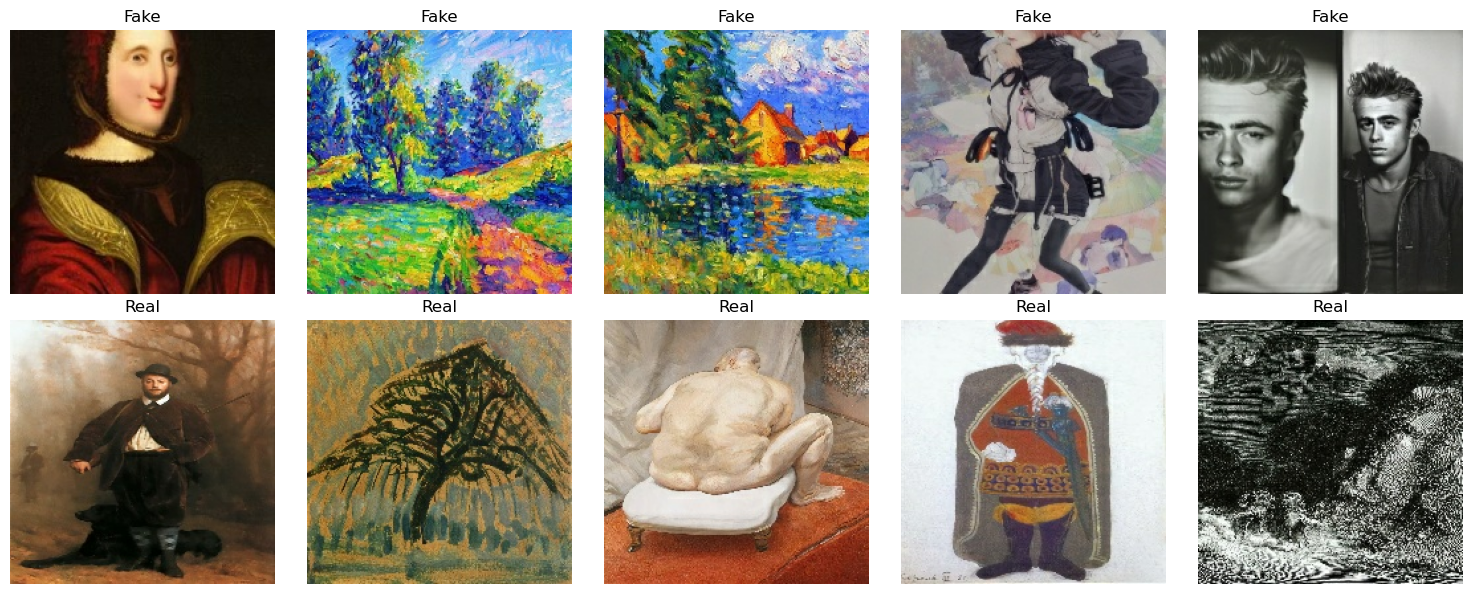

In [7]:
fake_images = []
real_images = []
num_images = 5


for images, labels in train_dataset:
    for i in range(images.shape[0]):
        # get the label value from the array
        label_index = int(labels[i].numpy())
        image = images[i].numpy()

        if class_names[label_index] == 'fake' and len(fake_images) < num_images:
            fake_images.append(image)
        elif class_names[label_index] == 'real' and len(real_images) < num_images:
            real_images.append(image)

    # break if needed
    if len(fake_images) >= num_images and len(real_images) >= num_images:
        break


fig, axes = plt.subplots(2, num_images, figsize=(15, 6))

for i in range(num_images):
    axes[0, i].imshow(fake_images[i] )
    axes[0, i].axis('off')
    axes[0, i].set_title('Fake')

    axes[1, i].imshow(real_images[i])
    axes[1, i].axis('off')
    axes[1, i].set_title('Real')

plt.tight_layout()
plt.show()

### Baseline model

For the baseline model on the Art dataset, we use a CNN with three convolutions with pooling blocks (32→64→128 filters), followed by a flatten, a 128-unit dense layer with 50% dropout, and a sigmoid output for binary classification. 

It’s compiled with Adam on binary crossentropy, tracks accuracy, precision, recall, and AUC, and is trained up to 10 epochs with early stopping and model checkpointing.

In [9]:
def create_baseline_model(input_shape=(200, 200, 3)):
    inputs = Input(shape=input_shape)

    # 1st convo
    x = Conv2D(32, (3, 3), activation='relu')(inputs)
    x = MaxPooling2D((2, 2))(x)

    # 2nd convo
    x = Conv2D(64, (3, 3), activation='relu')(x)
    x = MaxPooling2D((2, 2))(x)

    # 3rd convo
    x = Conv2D(128, (3, 3), activation='relu',
                      name='last_conv_layer')(x)
    x = MaxPooling2D((2, 2))(x)

    # flatten the output
    x = Flatten()(x)

    # fully connected layers
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)

    #  output layer
    outputs = layers.Dense(1, activation='sigmoid')(x)
    loss = 'binary_crossentropy'

    model = Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss=loss,
        metrics=['accuracy', Precision(), Recall(), AUC()]
    )

    return model


model = create_baseline_model(
        input_shape=(200, 200, 3)
)

model.summary()


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 200, 200, 3)]     0         
                                                                 
 conv2d (Conv2D)             (None, 198, 198, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 99, 99, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 97, 97, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 48, 48, 64)        0         
 g2D)                                                            
                                                                 
 last_conv_layer (Conv2D)    (None, 46, 46, 128)       73856 

In [12]:
# check for existing weights
history = None
if os.path.exists(f"{weigths_path}/art_baseline_model.h5"):
    print("Loading existing model weights...")
    model.load_weights(f"{weigths_path}/art_baseline_model.h5")
else:
    history = model.fit(
        train_dataset,
        validation_data=test_dataset,
        epochs=10,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(
                monitor='val_loss',
                patience=3,
                restore_best_weights=True
            ),
            tf.keras.callbacks.ModelCheckpoint(
                filepath=f"{weigths_path}/art_baseline_model.h5",
                save_best_only=True,
                monitor='val_loss',
                mode='min'
            )
        ]
    )

    # save the model weights
    model.save(f"{weigths_path}/art_baseline_model.h5")

Loading existing model weights...


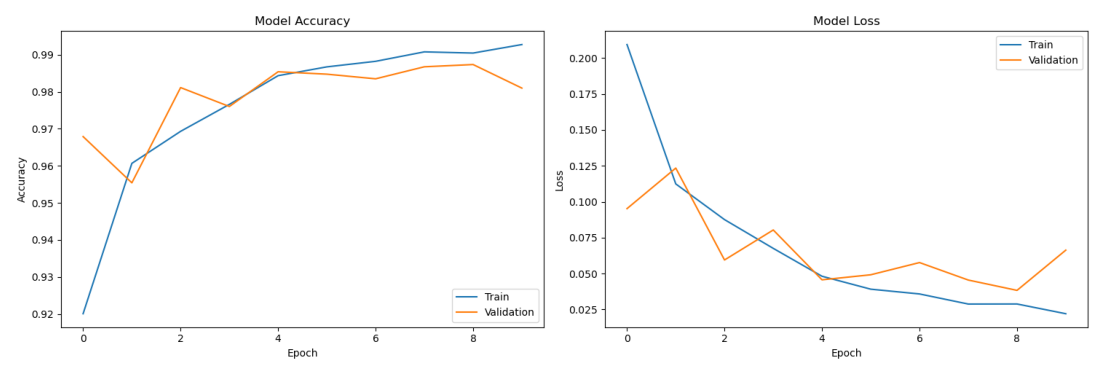

ValueError: not enough values to unpack (expected 5, got 2)

In [50]:
if history:
    plot_training_history(history)
else:
    # show the image saved in memory 
    history_image_path = "../images/art_baseline_history.png"
    
    # show image 
    plt.figure(figsize=(14, 8))
    img = plt.imread(history_image_path)
    plt.imshow(img)
    plt.axis('off')
    plt.show()
    

test_loss, test_acc, test_precision, test_recall, test_auc = model.evaluate(
    test_dataset, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test precision: {test_precision:.4f}")
print(f"Test recall: {test_recall:.4f}")
print(f"Test AUC: {test_auc:.4f}")



Our baseline model has a test accuracy of 0.9810 which is already quite big a baseline model. The goal for our refined model would have to be the closest a possible to the 100% accuracy without over-fitting.

### Refined model

Even though our baseline is already great, we tried to push the test accuracy further by swithing to a deeper network with skip-connections so we can learn trickier patterns without losing what we’ve already picked up. 

Instead of flattening every feature map, we use global average pooling and a bigger dense layer, and we sprinkled in batch normalization plus a smart learning-rate scheduler so training runs smoother and can stretch out to 20 epochs

In [17]:
# residual block
def residual_block(x, filters, kernel_size=3, stride=1,last=False):
    shortcut = x
    x = Conv2D(filters, kernel_size, strides=stride, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = Conv2D(filters, kernel_size, strides=1, padding='same')(x)
    x = BatchNormalization()(x)
    
    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = Conv2D(filters, kernel_size=1,
                          strides=stride, padding='same')(shortcut)
        shortcut = BatchNormalization()(shortcut)
    x = Add()([x, shortcut])
    x = Activation('relu')(x)
    return x



def create_model(input_shape=(200, 200, 3)):
    input_layer = Input(shape=input_shape)

    # 1st conv
    x = Conv2D(32, (3, 3), strides=1, padding='same')(input_layer)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D((2, 2))(x)

    # 1st residual set
    x = residual_block(x, 64, stride=1)
    x = residual_block(x, 64, stride=1)
    x = MaxPooling2D((2, 2))(x)

    # 2nd residual set
    x = residual_block(x, 128, stride=1)
    x = residual_block(x, 128, stride=1)
    x = MaxPooling2D((2, 2))(x)

    # 3rd residual set
    x = residual_block(x, 256, stride=1)
    x = residual_block(x, 256, stride=1)

    # use global average pooling to reduce the spatial dimensions
    x = GlobalAveragePooling2D()(x)
    
    # fully connected layers
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)


    output_layer = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=input_layer, outputs=output_layer)
    model.compile(optimizer='adam', loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model


model = create_model()
model.summary()

# callbacks
lr_plateau = ReduceLROnPlateau(
    monitor='val_loss',    
    factor=0.5,            
    patience=3,            
    verbose=1,
    min_lr=1e-6
)
early_stop = EarlyStopping(
    monitor='val_loss',    
    patience=5,            
    restore_best_weights=True,
    verbose=1
)
checkpoint = ModelCheckpoint(
    filepath=f"{weigths_path}/art_best_model.h5",      
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)


Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 200, 200, 3)]        0         []                            
                                                                                                  
 conv2d_2 (Conv2D)           (None, 200, 200, 32)         896       ['input_2[0][0]']             
                                                                                                  
 batch_normalization (Batch  (None, 200, 200, 32)         128       ['conv2d_2[0][0]']            
 Normalization)                                                                                   
                                                                                                  
 activation (Activation)     (None, 200, 200, 32)         0         ['batch_normalization[0]

In [19]:
history = None
# check for existing weights
if os.path.exists(f"{weigths_path}/art_best_model.h5"):
    print("Loading existing model weights...")
    model.load_weights(f"{weigths_path}/art_best_model.h5")
    print("Model loaded")
else:        
    # training
    history = model.fit(
        train_dataset,
        validation_data=test_dataset,
        epochs=20,  
        callbacks=[lr_plateau, early_stop, checkpoint]
    )
     
    # save the model weights
    model.save(f"{weigths_path}/art_best_model.h5")

Loading existing model weights...
Model loaded


### Model evaluation

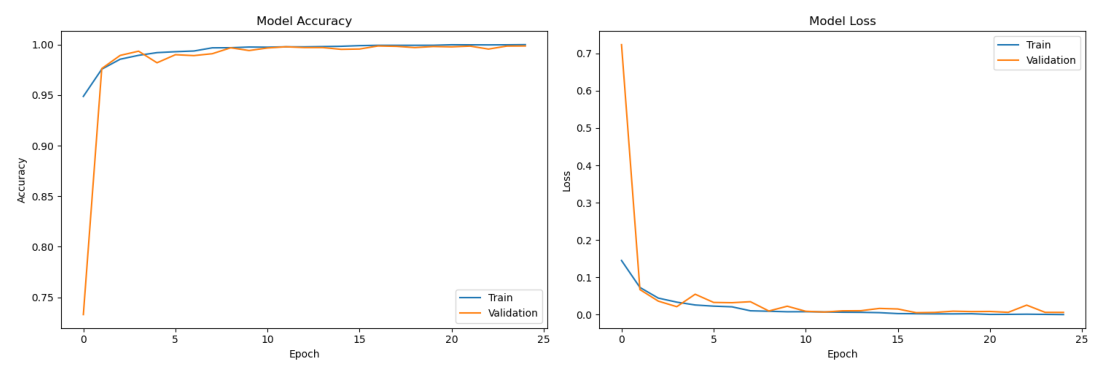

Test accuracy: 0.9987


In [20]:
if history:
    # plot the training history
    plot_training_history(history)
    
else: 
    # show the image saved in memory 
    history_image_path = "../images/art_refined_history.png"
    
    #show image 
    plt.figure(figsize=(14, 8))
    img = plt.imread(history_image_path)
    plt.imshow(img)
    plt.axis('off')
    plt.show()
    
# evaluate the model
test_loss, test_acc = model.evaluate(test_dataset, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")
    


**We obtained a test accuracy of 99.87% !**
It's almost perfect, now let's try to understand why we were able to reach such a high level of accuracy

#### Saliency Map and Grad-CAM heatmap

/tmp/ipykernel_18194/2470748013.py:214: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(labels[i].numpy())
/tmp/ipykernel_18194/897716888.py:50: RuntimeWarning: invalid value encountered in cast
  heatmap = np.uint8(255* heatmap)


Last convolutional layer name: conv2d_17


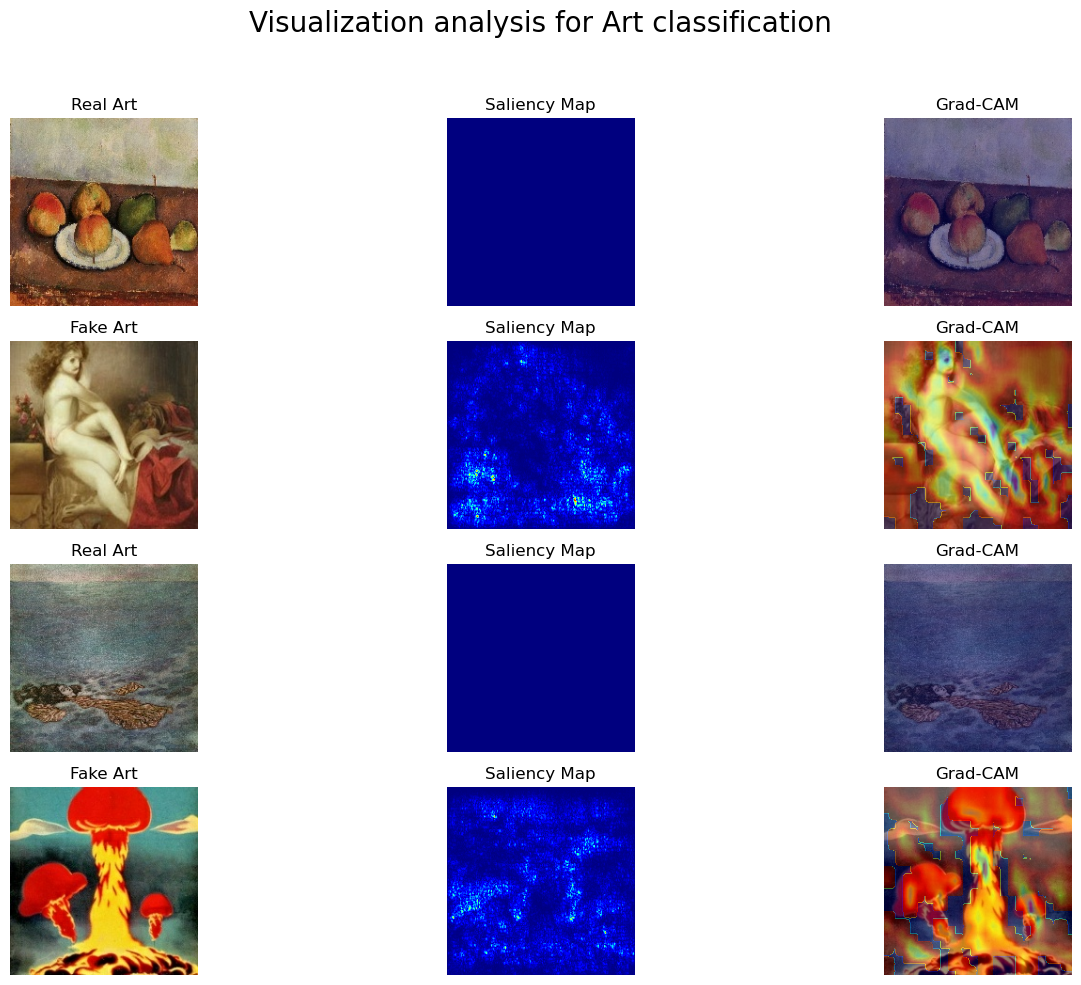

In [48]:
sample_images, sample_labels = get_sample_images(test_dataset, num_samples=5)

# we need to extract the name from the model
last_conv_layer_name = None
for layer in model.layers:
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer_name = layer.name

print(f"Last convolutional layer name: {last_conv_layer_name}")

# Grad-CAM and Saliency maps 
plt.figure(figsize=(15, 10))
plt.suptitle("Visualization analysis for Art classification", fontsize=20)

for i, (img, label) in enumerate(zip(sample_images[:4], sample_labels[:4])):
    # original image
    plt.subplot(4, 3, i*3+1)
    plt.imshow(img)
    plt.title(f"{'Real' if label==1 else 'Fake'} Art")
    plt.axis('off')
    
    # Saliency map
    saliency = compute_saliency_map(model, img, target_class=label)
    plt.subplot(4, 3, i*3+2)
    plt.imshow(saliency, cmap='jet')
    plt.title("Saliency Map")
    plt.axis('off')
    
    # Grad-CAM
    plt.subplot(4, 3, i*3+3)
    plt.imshow(img)
    
    # Grad-CAM heatmap
    img_tensor = np.expand_dims(img, axis=0)
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_tensor)
        loss = predictions[:, 0] 
    
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    heatmap = heatmap.numpy()
    heatmap = np.uint8(255* heatmap)
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    
    # use an overlay heatmap on the original image
    plt.imshow(heatmap, cmap='jet', alpha=0.4)
    plt.title("Grad-CAM")
    plt.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


#### Confusion matrix

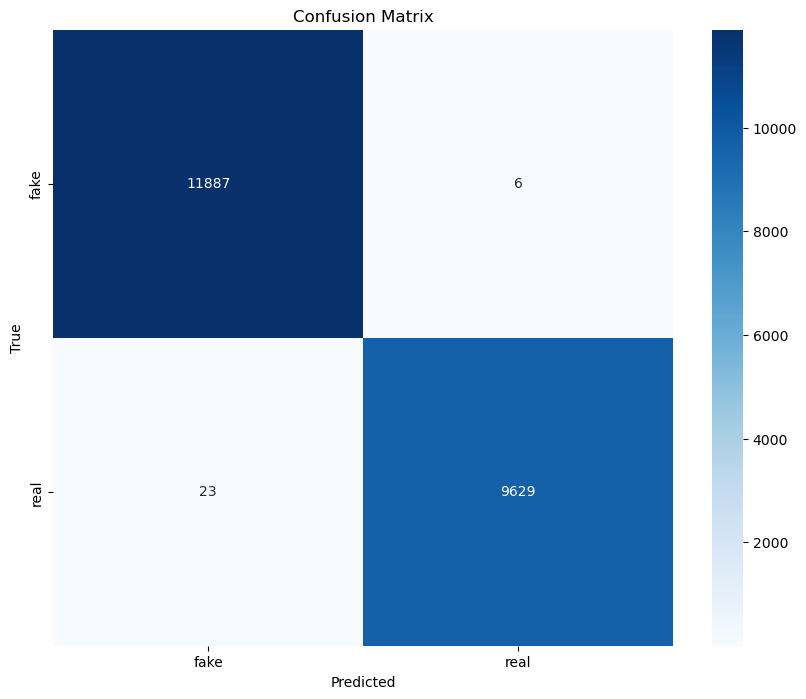

Classification Report:
              precision    recall  f1-score   support

        fake       1.00      1.00      1.00     11893
        real       1.00      1.00      1.00      9652

    accuracy                           1.00     21545
   macro avg       1.00      1.00      1.00     21545
weighted avg       1.00      1.00      1.00     21545


Detailed Metrics:
True Negatives (correctly identified fake): 11887
False Positives (fake identified as real): 6
False Negatives (real identified as fake): 23
True Positives (correctly identified real): 9629
Precision: 0.9994
Recall: 0.9976
F1 Score: 0.9985


In [30]:
y_pred, y_true = get_predictions_and_labels(test_dataset, model)
cm = confusion_matrix(y_true, y_pred)

# plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# classification report
report = classification_report(y_true, y_pred, target_names=class_names)
print("Classification report:\n")
print(report)

# metrics
tn, fp, fn, tp = cm.ravel()
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"Metrics:")
print(f"True negatives (correctly identified fake): {tn}")
print(f"False positives (fake identified as real): {fp}")
print(f"False negatives (real identified as fake): {fn}")
print(f"True positives (correctly identified real): {tp}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 score: {f1:.4f}")

### Analysis on misclassfied examples with Grad-cam and Saliency MAP

/tmp/ipykernel_18194/2470748013.py:291: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  true_label = int(labels[i].numpy())


Found 18208 confident correct predictions
Found 23 incorrect predictions
Found 5 uncertain predictions

Visualizing incorrect predictions:


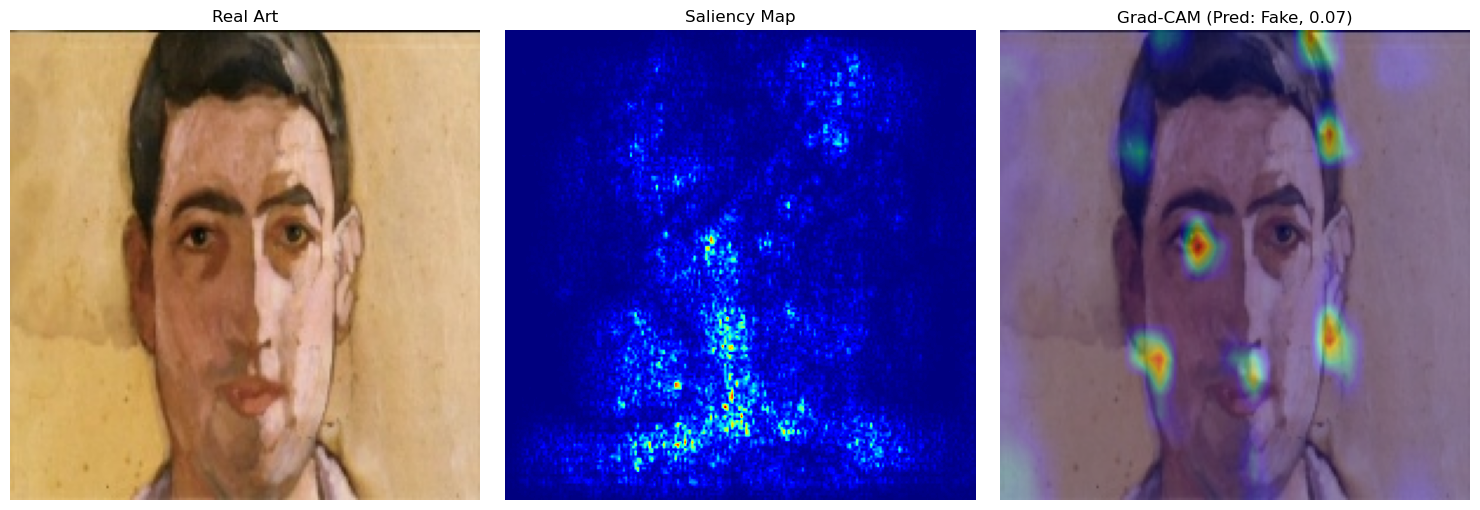

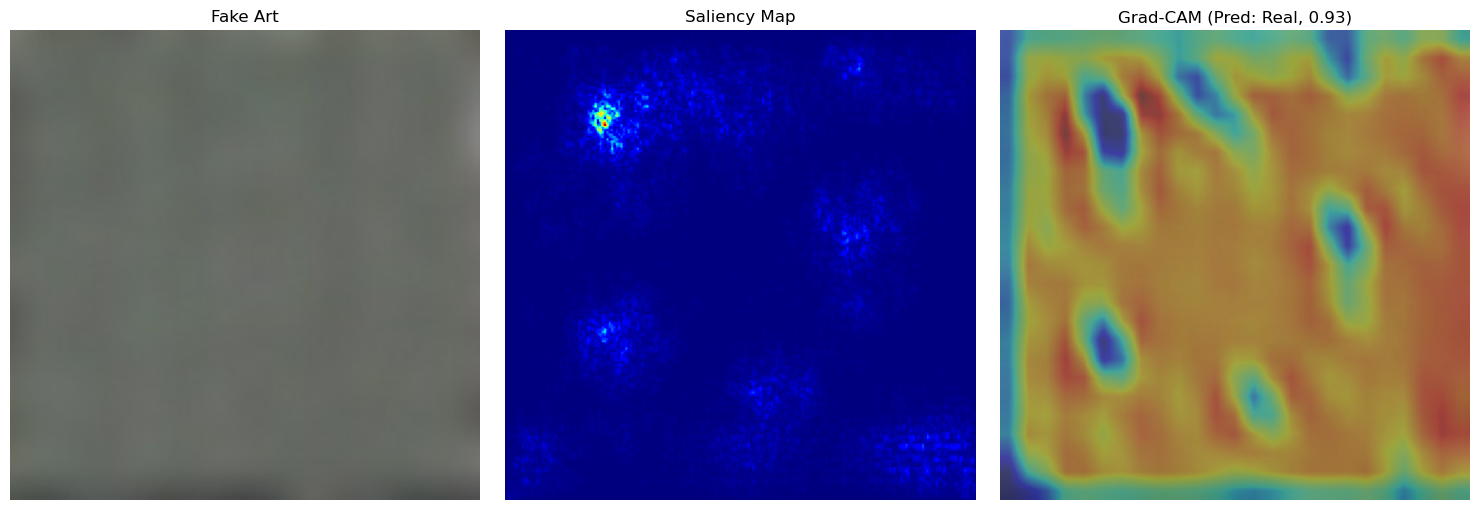


Visualizing uncertain predictions:


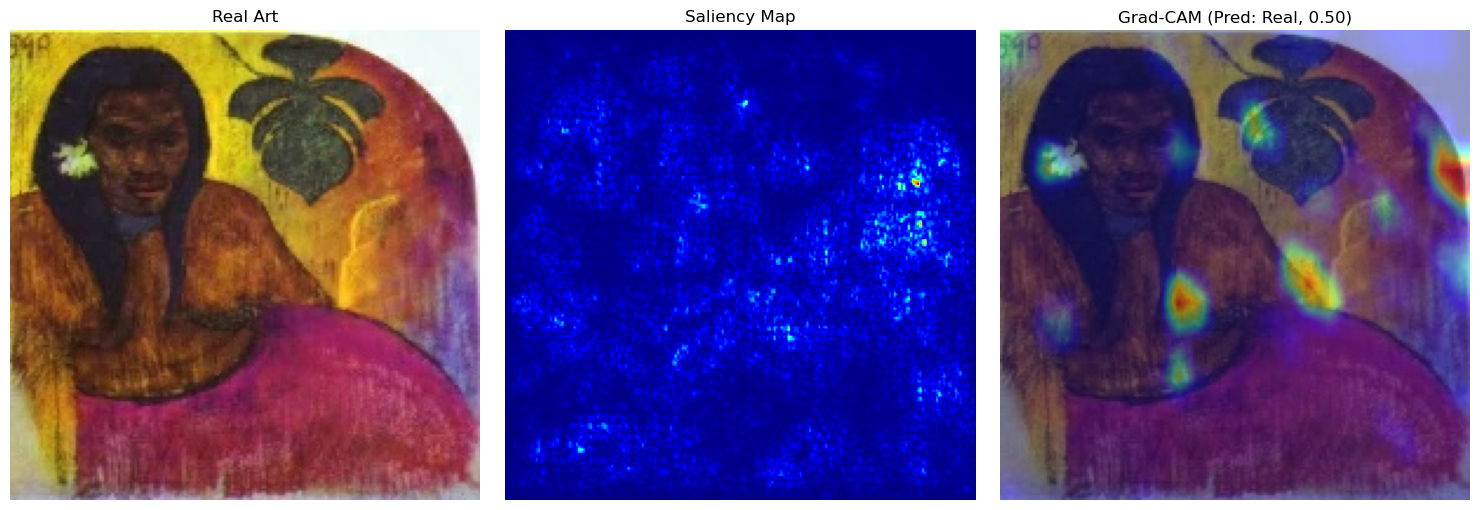

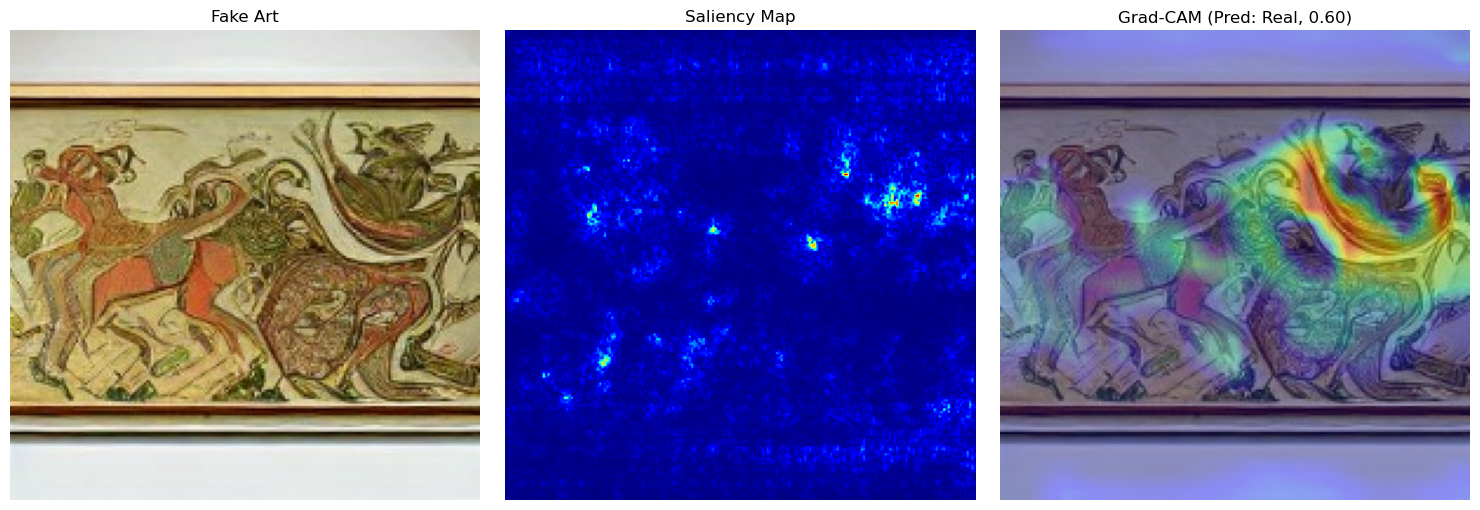

In [49]:
# get misclassified and confident predictions
correct_confident, incorrect, unsure = find_interesting_examples(test_dataset, model)

print(f"Found {len(correct_confident)} confident correct predictions")
print(f"Found {len(incorrect)} incorrect predictions")
print(f"Found {len(unsure)} uncertain predictions")

# plot
print("\nVisualizing incorrect predictions:")
for img, true_label, pred_prob in incorrect[:2]:
    visualize_single_image(model, img, last_conv_layer_name, true_label)

print("\nVisualizing uncertain predictions:")
for img, true_label, pred_prob in unsure[:2]:
    visualize_single_image(model, img, last_conv_layer_name, true_label)

#### ROC and AUC

Area Under the ROC Curve (AUC): 0.999969
Optimal threshold: 0.3459


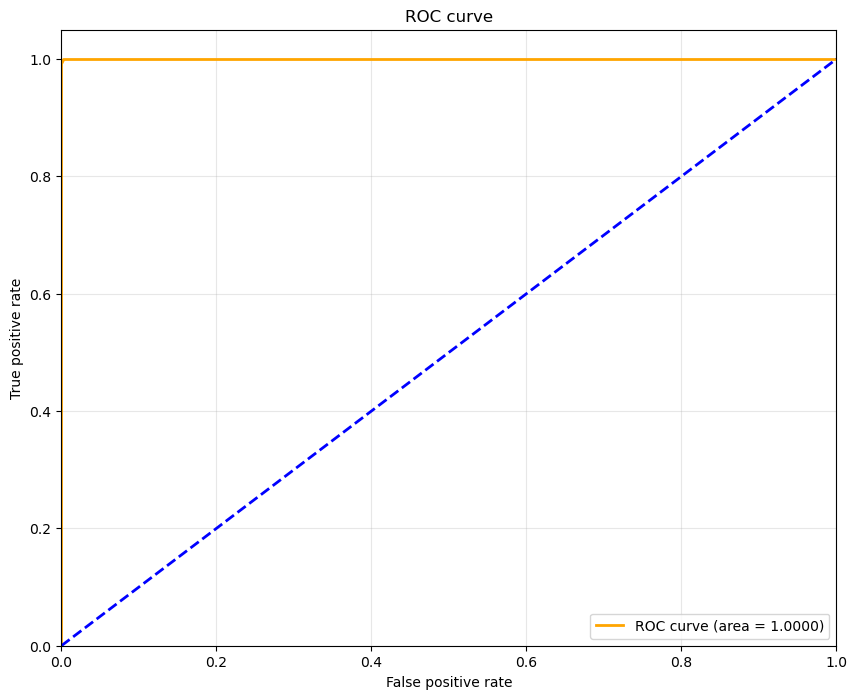

In [36]:
y_prob, y_true = get_probabilities_and_labels(test_dataset, model)

# roc and AUC
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

# plot
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='orange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='blue', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

print(f"Area Under the ROC Curve (AUC): {roc_auc:.6f}")

optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print(f"Optimal threshold: {optimal_threshold:.4f}")

### Performances analysis

Our CNN is almost perfect at detecting AI-made art: it scored 99.87% accuracy on over 21500 test images, with only 6 fake‐as‐real and 23 real‐as‐fake mistakes. Its precision of 0.9994, recall of 0.9976, and F1‐score of 0.9985 show it rarely misses or mislabels, hence a good model

We use heatmaps and Grad-CAM to explain how it works. On fake images, it lights up odd textures and warped edges that AI tools often leave behind (that can be hard to see to the naked eye). On real paintings, its attention is softer and spread over genuine brushstrokes and natural color shifts